In [169]:
import matplotlib.pyplot as plt
from __future__ import annotations
from pyprojroot import here
import datetime as dt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

In [170]:
ROOT_DIR = here()
DATA_DIR = ROOT_DIR / "data" / "processed"

base_data = pd.read_csv(DATA_DIR / "df_full.csv", parse_dates=["datetime"])


In [171]:
base_data.set_index("datetime", inplace=True)

In [ ]:
# Default quantile levels — 19 levels, matching the Pinson scenario setup.
QUANTILE_LEVELS = np.round(np.arange(0.05, 0.96, 0.05), 2)


# --------------------------------------------------------------------------- #
# 1. Feature engineering (calendar + weather), following vom Scheidt's features
# --------------------------------------------------------------------------- #


def build_features(df: pd.DataFrame,
                   prosumption_col: str = "prosumption",
                   feature_cols=("irradiance_Wm-2", "panel_temp_C", "temp_location3")) -> pd.DataFrame:
    """
    df: DatetimeIndex (hourly), columns = [load_col, *feature_cols].
    Returns a frame with the prosumption, plus calendar features (hour-of-day
    and weekday, both cyclical) and the feature columns. Cyclical encoding is used
    for hour-of-day and day-of-week, but one-hot for weekends.
    """
    out = pd.DataFrame(index=df.index)
    out[prosumption_col] = df[prosumption_col].astype(float)
    dateindex = df.index
    #Calendar features
    hr = dateindex.hour.values
    dow   = dateindex.dayofweek.values
    #mon       = dateindex.month.values
    doy   = dateindex.dayofyear.values
    is_weekend  = (dateindex.dayofweek >= 5).astype(int)

    #Cyclical encodings
    out["hour_sin"]   = np.sin(2 * np.pi * hr / 24)
    out["hour_cos"]   = np.cos(2 * np.pi * hr / 24)
    out["dow_sin"]    = np.sin(2 * np.pi * dow / 7)
    out["dow_cos"]    = np.cos(2 * np.pi * dow / 7)
    out["doy_sin"]    = np.sin(2 * np.pi * doy / 365.25)
    out["doy_cos"]    = np.cos(2 * np.pi * doy / 365.25)
    out["is_weekend"] = is_weekend
    for c in feature_cols:
        if c in df.columns:
            out[c] = df[c].astype(float)

    return out

HIST_COLS_DEFAULT = ["prosumption", "irradiance_Wm-2", "panel_temp_C", "temp_location3"]
FEAT_COLS_DEFAULT = ["irradiance_Wm-2", "panel_temp_C", "temp_location3"]
EXO_COLS_DEFAULT = ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "doy_sin", "doy_cos", "is_weekend"]

In [ ]:
frame_full = build_features(base_data, feature_cols=FEAT_COLS_DEFAULT)
if frame_full.index.tz is None:
    frame_full = frame_full.tz_localize("UTC")
else:
    frame_full = frame_full.tz_convert("UTC")

In [ ]:
def make_windows(
    frame: pd.DataFrame,
    n_hist: int = 168,
    horizon: int = 24,
    exo_cols: list[str] = ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "doy_sin", "doy_cos", "is_weekend"],
    hist_cols: list[str] = ["prosumption", "irradiance_Wm-2", "panel_temp_C", "temp_location3"],
    target_col: str = "prosumption",
    issue_hour: int = 9,               # hour-of-day the forecast is issued (gate closure)
    gate_aligned_only: bool = False,   # False = all-hours rolling origins (baseline augmentation); True = one daily gate origin (DFL / frozen artefacts)
    lead_gap: int | None = None,       # last-obs -> first delivery step; default 24 - issue_hour => next-day 00:00 first delivery
    y_range: tuple[pd.Timestamp, pd.Timestamp] | None = None,  # keep windows whose ENTIRE delivery block falls in [y_start, y_end] inclusive
) -> tuple[np.ndarray, np.ndarray, np.ndarray, pd.DatetimeIndex]:
    """
    Build forecaster windows, with split membership defined by the TARGET (delivery) window.

    A window is kept iff:
      - it has n_hist hours of history before the origin, and
      - its full delivery block [d0 .. d0+horizon-1] lies within the frame, and
      - (if y_range given) that full delivery block lies within [y_start, y_end] inclusive.

    Split cleanliness: because the ENTIRE delivery block must sit inside y_range,
    adjacent splits share zero target hours -> no target leakage across boundaries,
    with no gap arithmetic required. History may (and for early targets must) reach
    back before y_start: pass a frame that extends >= (n_hist + lead_gap) hours before
    y_start so the earliest in-period targets are not dropped for lack of history.

    y_range should be given per split, e.g.:
        train: (TRAIN_START, VAL_START  - 1h)
        val:   (VAL_START,   TEST_START - 1h)
        test:  (TEST_START,  TEST_END)
    (the -1h keeps the day-boundary exclusive so splits abut without overlapping.)
    """
    # --- integrity: positional slicing assumes a sorted, gap-free, regular hourly (UTC) grid ---
    if not frame.index.is_monotonic_increasing:
        raise ValueError("frame index must be sorted ascending")
    steps = frame.index.to_series().diff().dropna().unique()
    if len(steps) != 1 or steps[0] != pd.Timedelta(hours=1):
        raise ValueError(f"index must be a complete regular hourly grid (found steps: {steps}). "
                         "Reindex to a full hourly UTC range before windowing.")

    

    if lead_gap is None:
        lead_gap = 24 - issue_hour     # issue 09:00 -> first delivery = next-day 00:00 (+15..+38h)

    hist  = frame[hist_cols].values.astype(np.float32)   # (T, C_hist)
    exo   = frame[exo_cols].values.astype(np.float32)    # (T, F_exo)
    y_all = frame[target_col].values.astype(np.float32)  # (T,)
    idx   = frame.index
    T     = len(frame)

    y_lo = pd.Timestamp(y_range[0]) if y_range is not None else None
    y_hi = pd.Timestamp(y_range[1]) if y_range is not None else None

    candidates = (np.where(idx.hour == issue_hour)[0] if gate_aligned_only
                  else np.arange(T))

    xh, xf, ys, timeind, delivery_start= [], [], [], [], []
    for i in candidates:
        d0   = i + lead_gap            # first delivery index
        last = d0 + horizon - 1        # last delivery index
        # history present AND full delivery block in-frame
        if i - n_hist < 0 or last >= T:
            continue
        # full delivery block inside the target range (both ends) -> no boundary crossing
        if y_lo is not None and (idx[d0] < y_lo or idx[last] > y_hi):
            continue
        xh.append(hist[i - n_hist:i])          # (n_hist, C_hist) up to ** AN HOUR BEFORE** gate closure
        xf.append(exo[d0:d0 + horizon])        # (horizon, F_exo) over delivery window
        ys.append(y_all[d0:d0 + horizon])      # (horizon,)       over delivery window

        timeind.append(i)
        delivery_start.append(idx[d0])


    x_hist = np.asarray(xh, dtype=np.float32)  # (N, n_hist, C_hist)
    x_fut  = np.asarray(xf, dtype=np.float32)  # (N, horizon, F_exo)
    y      = np.asarray(ys, dtype=np.float32)  # (N, horizon)

    # catch errors if no valid window found
    if not timeind:
        raise ValueError("no windows produced — check y_range, frame extent, or n_hist/lead_gap")

    # tracking of history start end, delivery start end for data normalisation
    hs = idx[min(timeind) - n_hist]
    he = idx[max(timeind) - 1]
    ds = idx[min(timeind) + lead_gap] 
    de = idx[max(timeind)+ lead_gap + horizon - 1]

    return (x_hist, x_fut, y, 
            pd.DatetimeIndex(delivery_start), hs, he, ds, de)

In [175]:
TRAIN_START = pd.Timestamp("2018-01-01 00:00:00+00:00")
VAL_START   = pd.Timestamp("2019-11-01 00:00:00+00:00")
TEST_START  = pd.Timestamp("2020-01-01 00:00:00+00:00")
TEST_END    = pd.Timestamp("2020-06-30 23:00:00+00:00")

In [176]:
h = pd.Timedelta(hours=1)
Xtr = make_windows(frame_full, y_range=(TRAIN_START, VAL_START  - h))
Xva = make_windows(frame_full, y_range=(VAL_START,   TEST_START - h))
Xte = make_windows(frame_full, y_range=(TEST_START,  TEST_END))

In [177]:
Xtr

(array([[[4.1000e+00, 9.3700e+00, 8.0600e+00, 7.8900e+00],
         [4.4000e+00, 2.3470e+01, 8.5100e+00, 8.3900e+00],
         [4.1700e+00, 5.8230e+01, 9.3500e+00, 8.9700e+00],
         ...,
         [2.1300e+00, 0.0000e+00, 8.6200e+00, 9.8100e+00],
         [2.2200e+00, 0.0000e+00, 8.8100e+00, 9.0100e+00],
         [2.7800e+00, 9.9000e-01, 9.4900e+00, 8.7400e+00]],
 
        [[4.4000e+00, 2.3470e+01, 8.5100e+00, 8.3900e+00],
         [4.1700e+00, 5.8230e+01, 9.3500e+00, 8.9700e+00],
         [4.2200e+00, 5.1100e+01, 8.9900e+00, 9.3400e+00],
         ...,
         [2.2200e+00, 0.0000e+00, 8.8100e+00, 9.0100e+00],
         [2.7800e+00, 9.9000e-01, 9.4900e+00, 8.7400e+00],
         [3.3800e+00, 2.6630e+01, 9.9100e+00, 8.6900e+00]],
 
        [[4.1700e+00, 5.8230e+01, 9.3500e+00, 8.9700e+00],
         [4.2200e+00, 5.1100e+01, 8.9900e+00, 9.3400e+00],
         [3.9900e+00, 8.8080e+01, 9.5500e+00, 9.4900e+00],
         ...,
         [2.7800e+00, 9.9000e-01, 9.4900e+00, 8.7400e+00],
        

In [178]:
QUANTILE_LEVELS = np.round(np.arange(0.05, 0.96, 0.05), 2)
NUM_QUANTILES = len(QUANTILE_LEVELS)

class Baseline_Forecaster(nn.Module):
    def __init__(self, n_hist_features, n_exo_features, horizon=24,
                 n_quantiles=len(QUANTILE_LEVELS), gru_hidden=32, n_gru_layers=2,
                 dense_hidden=64, dropout=0.1, eps=1e-4):
        """
        n_hist_features : channels in the history window (e.g. consumption +
                          panel temp + outside temp + irradiance = 4).
        n_exo_features  : per-horizon calendar features (cyclical hour, is_weekend...).
        """
        super().__init__()
        self.horizon = horizon
        self.n_quantiles = n_quantiles
        self.eps = eps

        # ---- Encoder: two stacked GRUs; take the top layer's final state ----
        # num_layers=2 stacks GRU-1 -> GRU-2 (GRU-1 feeds its full sequence to
        # GRU-2 internally, i.e. return_sequences=True between the layers).
        self.encoder = nn.GRU(
            input_size=n_hist_features, hidden_size=gru_hidden,
            num_layers=n_gru_layers, batch_first=True,
            dropout=dropout if n_gru_layers > 1 else 0.0,
        )

        # ---- Decoder: shared dense head, applied at each horizon step ----
        # Applying these Linears over a (B, horizon, .) tensor shares the weights
        # across the 24 steps by construction.
        self.decoder = nn.Sequential(
            nn.Linear(gru_hidden + n_exo_features, dense_hidden), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dense_hidden, dense_hidden), nn.ReLU(),
            nn.Linear(dense_hidden, n_quantiles),
        )

    def forward(self, x_hist, x_exo):
        """
        x_hist : (Batch, L, n_hist_features)      history (realised consumption + weather)
        x_exo  : (Batch, horizon, n_exo_features) per-horizon (time-respective) calendar
        returns: (Batch, horizon, n_quantiles)    monotone quantiles (increasing in Q)
        """
        # Encoder -> single history encoding (final hidden state of the top GRU)
        _, h_n = self.encoder(x_hist)                 # h_n: (n_layers, B, H)
        encoding = h_n[-1]                            # (B, H)

        # Reuse the encoding across all horizon steps; concat per-step calendar
        B, K, _ = x_exo.shape
        enc = encoding.unsqueeze(1).expand(B, K, encoding.shape[-1])  # (B, K, H)
        dec_in = torch.cat([enc, x_exo], dim=-1)      # (B, K, H + n_exo)

        # Shared dense head at each step -> raw quantile values
        raw = self.decoder(dec_in)                    # (B, K, Q)

        # Monotone construction: base + cumulative (softplus + eps) increments
        base = raw[..., 0:1]                          # lowest quantile (0.05)
        inc = F.softplus(raw[..., 1:]) + self.eps     # strictly positive
        quantiles = torch.cat(
            [base, base + torch.cumsum(inc, dim=-1)], dim=-1)  # (B, K, Q)
        return quantiles


def pinball_loss(y_true, y_pred, levels):
    """
    y_true : (B, K)      standardised targets
    y_pred : (B, K, Q)   monotone quantile forecasts
    levels : (Q,) tensor
    Summed pinball over levels approximates CRPS, aligning the training objective
    with the reported metric.
    """
    e = y_true.unsqueeze(-1) - y_pred                 # (B, K, Q)
    q = levels.view(1, 1, -1)
    return torch.maximum(q * e, (q - 1.0) * e).mean()


## Test 1: Train on a month of data

In [179]:
## get data
MONTH_TRAIN_START = pd.Timestamp("2018-01-01 00:00:00+00:00")
MONTH_TRAIN_END = pd.Timestamp("2018-06-30 23:00:00+00:00")
MONTH_VAL_START = pd.Timestamp("2018-07-01 00:00:00+00:00")
MONTH_VAL_END = pd.Timestamp("2018-07-31 23:00:00+00:00")

Mtr = make_windows(frame_full, y_range=(MONTH_TRAIN_START, MONTH_TRAIN_END))
Mval = make_windows(frame_full, y_range=(MONTH_VAL_START, MONTH_VAL_END))

In [189]:
len(Mval)

8

In [202]:
x_hist_tr, x_fut_tr, Y_tr, delivery_start, hs, he, ds, de = Mtr
x_hist_val, x_fut_val, Y_val, _, _, _, _, _ = Mval

In [181]:
def fit_scalers(frame_slice, hist_cols, target_col="prosumption"):
    """
    frame_slice : raw rows the TRAINING windows touch, e.g. frame.loc[hs:de]
                  (each hour counted once — no window double-counting).
    hist_cols   : channel order of x_hist, e.g.
                  ["prosumption", "irradiance_Wm-2", "panel_temp_C", "temp_location3"]
    Returns a dict of frozen stats.
    """
    mu_hist = np.array([frame_slice[c].mean() for c in hist_cols], dtype=np.float32)
    sd_hist = np.array([frame_slice[c].std()  for c in hist_cols], dtype=np.float32)
    sd_hist[sd_hist == 0] = 1.0
    # target shares the prosumption series -> same scaler (computed from same column)
    mu_y = float(frame_slice[target_col].mean())
    sd_y = float(frame_slice[target_col].std() or 1.0)
    return {"hist_cols": list(hist_cols),
            "mu_hist": mu_hist, "sd_hist": sd_hist, "mu_y": mu_y, "sd_y": sd_y}
 
 
def normalise_hist(x_hist, scalers):
    """x_hist: (N, L, C) aligned to scalers['hist_cols']. Per-channel z-score."""
    return ((x_hist - scalers["mu_hist"]) / scalers["sd_hist"]).astype(np.float32)
 
 
def normalise_y(y, scalers):
    """y: (N, horizon) prosumption target -> standardised with the shared scaler."""
    return ((y - scalers["mu_y"]) / scalers["sd_y"]).astype(np.float32)
 
 
def denormalise_y(y_std, scalers):
    """Predictions -> physical MW. Works for point (N,K) or quantiles (N,K,Q),
    numpy or torch (scalar affine, positive scale -> monotonicity preserved)."""
    assert scalers["sd_y"] > 0
    return y_std * scalers["sd_y"] + scalers["mu_y"]

In [192]:
frame_full[hist_cols]

,prosumption,irradiance_Wm-2,panel_temp_C,temp_location3
datetime,,,,
2017-11-03 00:00:00+00:00,2.19,0.00,7.05,7.46
2017-11-03 01:00:00+00:00,2.01,0.00,7.70,7.14
2017-11-03 02:00:00+00:00,1.86,0.00,7.20,6.86
2017-11-03 03:00:00+00:00,1.72,0.00,7.97,6.60
2017-11-03 04:00:00+00:00,1.62,0.00,7.85,6.86
...,...,...,...,...
2020-07-09 19:00:00+00:00,2.66,65.07,15.65,15.35
2020-07-09 20:00:00+00:00,2.62,4.30,12.13,14.63
2020-07-09 21:00:00+00:00,2.59,0.00,11.18,14.18


In [193]:
sc

{'hist_cols': ['prosumption',
  'irradiance_Wm-2',
  'panel_temp_C',
  'temp_location3'],
 'mu_hist': array([  2.3752303, 156.92068  ,  10.675928 ,   8.540658 ], dtype=float32),
 'sd_hist': array([  1.4807036, 260.1888   ,   9.312465 ,   5.4765673], dtype=float32),
 'mu_y': 2.3752302922940656,
 'sd_y': 1.4807036025048625}

In [199]:
xh_n[:, :, 0]

tensor([[ 1.1648,  1.3674,  1.2121,  ..., -0.1656, -0.1048,  0.2734],
        [ 1.3674,  1.2121,  1.2459,  ..., -0.1048,  0.2734,  0.6786],
        [ 1.2121,  1.2459,  1.0905,  ...,  0.2734,  0.6786,  1.0433],
        ...,
        [-0.6654, -1.4758, -2.1849,  ..., -0.5776, -0.3074, -0.1386],
        [-1.4758, -2.1849, -2.5631,  ..., -0.3074, -0.1386, -0.6654],
        [-2.1849, -2.5631, -2.7995,  ..., -0.1386, -0.6654, -1.3745]])

In [216]:
xh_n[:,:,0].shape

(4321, 168)

In [226]:
nan_mask = pd.isna(frame_full[hist_cols].loc[hs:de])
nan_count = int(nan_mask.sum())

print(f"NaN count in x_hist_tr: {nan_count}")
if nan_count > 0:
    first_nan = np.argwhere(nan_mask)[0]
    print("First NaN location:", tuple(first_nan))
else:
    print("No NaN values found in xh_n.")

NaN count in x_hist_tr: 43
First NaN location: (np.int64(1670), np.int64(2))


In [203]:
hist_cols = ["prosumption", "irradiance_Wm-2", "panel_temp_C", "temp_location3"]

# fit on the training span (each row once)
sc = fit_scalers( frame_full.loc[hs:de], hist_cols)

print("mu_hist:", np.round(sc["mu_hist"], 2), "sd_hist:", np.round(sc["sd_hist"], 2))
print("shared scaler check  mu_y == mu_hist[0]:",
        np.isclose(sc["mu_y"], sc["mu_hist"][0]),
        "| sd_y == sd_hist[0]:", np.isclose(sc["sd_y"], sc["sd_hist"][0]))

xh_n = normalise_hist(x_hist_tr, sc)
Y_n = normalise_y(Y_tr, sc)

xh_val_n = normalise_hist(x_hist_val, sc)
Y_val_n = normalise_y(Y_val, sc)
print("normalised hist ch0  mean/std:", round(xh_n[:, :, 0].mean(), 3), round(xh_n[:, :, 0].std(), 3))
print("normalised hist ch1  mean/std:", round(xh_n[:, :, 1].mean(), 3), round(xh_n[:, :, 1].std(), 3))
print("normalised y         mean/std:", round(Y_n.mean(), 3), round(Y_n.std(), 3))


x_hist.shape

num_hist = x_hist_tr.shape[2]
num_exo = x_fut_tr.shape[2]
horizon = 24

# return vector of size N, horizon, NUM_QUANTILES))
# q_mw = denormalise_y(return vector, sc)

# Convert Training Arrays
xh_n_t     = torch.as_tensor(xh_n, dtype=torch.float32)
x_fut_tr_t = torch.as_tensor(x_fut_tr, dtype=torch.float32)
Y_n_t      = torch.as_tensor(Y_n, dtype=torch.float32)

# Convert Validation Arrays
xh_val_n_t  = torch.as_tensor(xh_val_n, dtype=torch.float32)
x_fut_val_t = torch.as_tensor(x_fut_val, dtype=torch.float32)
Y_val_n_t   = torch.as_tensor(Y_val_n, dtype=torch.float32)

mu_hist: [  2.38 156.92  10.68   8.54] sd_hist: [  1.48 260.19   9.31   5.48]
shared scaler check  mu_y == mu_hist[0]: True | sd_y == sd_hist[0]: True
normalised hist ch0  mean/std: nan nan
normalised hist ch1  mean/std: nan nan
normalised y         mean/std: nan nan


In [183]:
QUANTILE_LEVELS_TENSOR = torch.as_tensor(QUANTILE_LEVELS, dtype=torch.float32)

model = Baseline_Forecaster(n_hist_features = num_hist, n_exo_features = num_exo, horizon=24,
                 n_quantiles=len(QUANTILE_LEVELS), gru_hidden=32, n_gru_layers=2,
                 dense_hidden=64, dropout=0.1, eps=1e-4)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

for epoch in range(150):
    model.train()
    perm = torch.randperm(len(xh_n))
    for i in range(0, len(Xtr), 64):
        b = perm[i:i + 64]
        opt.zero_grad()
        loss = pinball_loss(Y_n[b], model(xh_n[b],x_fut_tr[b]), QUANTILE_LEVELS_TENSOR)
        loss.backward()
        opt.step()
    if (epoch + 1) % 30 == 0:
        model.eval()
        with torch.no_grad():
            vl = pinball_loss(Y_val_n, model(xh_val_n, x_fut_val), QUANTILE_LEVELS_TENSOR).item()
        print(f"epoch {epoch + 1:3d} | val pinball {vl:.4f}")

epoch  30 | val pinball nan


epoch  60 | val pinball nan
epoch  90 | val pinball nan
epoch 120 | val pinball nan
epoch 150 | val pinball nan


In [184]:
model.eval()
with torch.no_grad():
    q_va = model(xh_val_n, x_fut_val)                       # (N, H, Q), standardised space
diffs = torch.diff(q_va, dim=-1)
print("monotone (all increments > 0):", bool((diffs > 0).all()))
print("min increment:", float(diffs.min()))

q_mw = denormalise_y(q_va, sc)
assert np.all(np.diff(q_mw, axis=-1) > 0), "physical-unit quantiles must stay ordered"
print("monotone after inverse-standardise: True")

monotone (all increments > 0): False
min increment: nan


AssertionError: physical-unit quantiles must stay ordered

In [ ]:
with torch.no_grad():
    cover = [(Y_val_n.unsqueeze(-1) <= q_va[..., k:k + 1]).float().mean().item()
             for k in range(len(QUANTILE_LEVELS))]
for a, c in zip(QUANTILE_LEVELS.tolist(), cover):
    print(f"level {a:.2f}:  empirical coverage {c:.3f}")

max_dev = max(abs(a - c) for a, c in zip(QUANTILE_LEVELS.tolist(), cover))
print(f"\nmax |coverage - nominal| = {max_dev:.3f}  (small = well calibrated)")

level 0.05:  empirical coverage 0.610
level 0.10:  empirical coverage 0.916
level 0.15:  empirical coverage 0.975
level 0.20:  empirical coverage 0.990
level 0.25:  empirical coverage 0.995
level 0.30:  empirical coverage 0.997
level 0.35:  empirical coverage 0.999
level 0.40:  empirical coverage 0.999
level 0.45:  empirical coverage 1.000
level 0.50:  empirical coverage 1.000
level 0.55:  empirical coverage 1.000
level 0.60:  empirical coverage 1.000
level 0.65:  empirical coverage 1.000
level 0.70:  empirical coverage 1.000
level 0.75:  empirical coverage 1.000
level 0.80:  empirical coverage 1.000
level 0.85:  empirical coverage 1.000
level 0.90:  empirical coverage 1.000
level 0.95:  empirical coverage 1.000

max |coverage - nominal| = 0.825  (small = well calibrated)


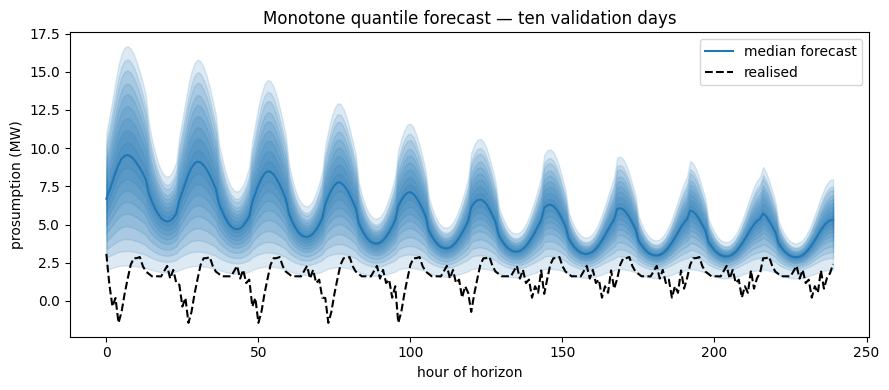

In [ ]:
Yva = Y_val[10:20].flatten()

hrs = np.arange(24*10)
qp = q_mw.numpy()[10:20].reshape(-1, 19)          # (H, Q) physical units
mid = len(QUANTILE_LEVELS) // 2

plt.figure(figsize=(9, 4))
for k in range(mid):                    # nested prediction bands
    plt.fill_between(hrs, qp[:, k], qp[:, -1 - k], alpha=0.15, color="C0")
plt.plot(hrs, qp[:, mid], color="C0", label="median forecast")
plt.plot(hrs, Yva, "k--", label="realised")
plt.xlabel("hour of horizon"); plt.ylabel("prosumption (MW)")
plt.title("Monotone quantile forecast — ten validation days")
plt.legend(); plt.tight_layout(); plt.show()

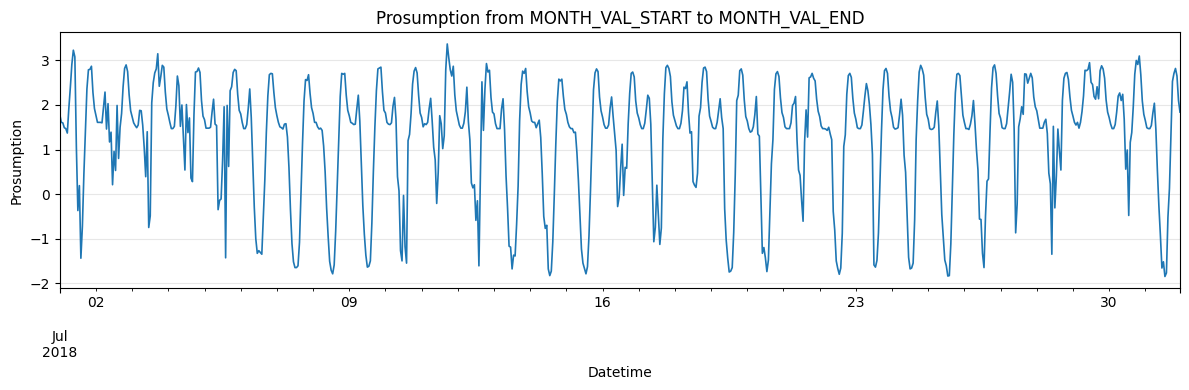

In [ ]:
s = frame_full.loc[MONTH_VAL_START:MONTH_VAL_END, "prosumption"]

plt.figure(figsize=(12, 4))
s.plot(color="C0", linewidth=1.2)
plt.title("Prosumption from MONTH_VAL_START to MONTH_VAL_END")
plt.xlabel("Datetime")
plt.ylabel("Prosumption")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()